# Mouse Visium HD dataset — characterization for the paper Data section

Describes the four-tissue mouse Visium HD dataset used for H&E-to-expression transfer:
per-tissue cell and gene counts, the predefined 100-gene variable-gene panel, the
random 70/15/15 cell-level split, and the spatial layout of each section.

Outputs are written as paper-ready CSV tables and PDF figures.


## Setup

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = Path('/hpc/group/jilab/tc459/MorphPT')

plt.rcParams.update({
    'figure.dpi':         110,
    'savefig.dpi':        220,
    'font.size':          10,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.titlelocation': 'left',
    'axes.titleweight':   'bold',
    'axes.titlesize':     11,
    'legend.frameon':     False,
})

## Configuration

Set `GENE_CSV_PATTERN` to whichever gene-selection CSV your random-split runs used.
The notebook takes the top-100 genes by variance rank from that file.

In [2]:
TISSUES = ['mouse_brain', 'mouse_intestine', 'mouse_kidney', 'mouse_embryo']

N_PANEL = 100   # top-N variable genes reported in the paper

TISSUE_COLORS = {
    'mouse_brain':     '#4C72B0',
    'mouse_intestine': '#55A868',
    'mouse_kidney':    '#C44E52',
    'mouse_embryo':    '#8172B2',
}

# Random split fractions (as used in --split_mode random)
SPLIT_FRACS = {'train': 0.70, 'val': 0.15, 'test': 0.15}

def cache_dir(tissue):
    return PROJECT / f'cache_{tissue}'

# Gene-selection CSV. {tissue} is substituted. Adjust this to the file your
# random-split training runs actually consumed via --top_csv.
# Example below assumes the top-500 variance CSV; the notebook subsets to top-100.
GENE_CSV_PATTERN = 'cache_{tissue}/splits/seed23/top500_variance_mincov0.1_train_seed23_seed42.csv'

def gene_csv(tissue):
    return PROJECT / GENE_CSV_PATTERN.format(tissue=tissue)

# Known canonical markers per tissue — used only to annotate the panel table.
KNOWN_MARKERS = {
    'mouse_brain':     {'Camk2n1', 'Nrgn', 'Apoe', 'Snap25', 'Mbp', 'Plp1', 'Gfap', 'Aqp4'},
    'mouse_intestine': {'Igkc', 'Fabp2', 'Reg3b', 'Reg3g', 'Muc2', 'Lyz1'},
    'mouse_kidney':    {'Kap', 'Umod', 'Slc34a1', 'Slc12a1', 'Aqp2', 'Nphs1'},
    'mouse_embryo':    {'Igf2', 'Col1a1', 'Col1a2', 'Hbb-bs', 'Afp', 'Myl7'},
}

## Dataset overview

Loads each tissue's `cache_stats.json`, `meta.csv`, and image memmaps to build the
master per-tissue summary table.

In [3]:
def load_cache_stats(tissue):
    p = cache_dir(tissue) / 'cache_stats.json'
    if p.exists():
        return json.loads(p.read_text())
    return {}

def image_patch_size(tissue, scale_tag):
    '''Read patch HxW from the image memmap header without loading it.'''
    p = cache_dir(tissue) / f'images_{scale_tag}.npy'
    if not p.exists():
        return None
    arr = np.load(p, mmap_mode='r')
    # expected shape: (n_cells, H, W, C) or (n_cells, C, H, W)
    if arr.ndim == 4:
        d = arr.shape
        # heuristic: channel dim is the size-3 axis
        if d[1] == 3:
            return (d[2], d[3])
        return (d[1], d[2])
    return arr.shape[1:]

rows = []
for tissue in TISSUES:
    stats = load_cache_stats(tissue)
    meta_p = cache_dir(tissue) / 'meta.csv'
    glist_p = cache_dir(tissue) / 'gene_list.txt'

    n_cells = stats.get('n_cells')
    if n_cells is None and meta_p.exists():
        n_cells = len(pd.read_csv(meta_p))

    n_genes_cached = stats.get('n_genes') or stats.get('n_genes_kept')
    if n_genes_cached is None and glist_p.exists():
        n_genes_cached = sum(1 for _ in open(glist_p))

    meta = pd.read_csv(meta_p) if meta_p.exists() else pd.DataFrame()
    n_tiles = meta['tile_id'].nunique() if 'tile_id' in meta.columns else None

    rows.append({
        'tissue':          tissue.replace('mouse_', ''),
        'n_cells':         n_cells,
        'n_genes_raw':     stats.get('n_genes_raw'),
        'n_genes_cached':  n_genes_cached,
        'coverage_filter': stats.get('coverage_threshold', stats.get('min_coverage')),
        'grid_size':       stats.get('grid_size'),
        'n_tiles':         n_tiles,
        'patch_2.5x':      image_patch_size(tissue, '2.5x'),
        'patch_10x':       image_patch_size(tissue, '10.0x'),
        'n_train':         int(n_cells * SPLIT_FRACS['train']) if n_cells else None,
        'n_val':           int(n_cells * SPLIT_FRACS['val'])   if n_cells else None,
        'n_test':          None if n_cells is None else
                           n_cells - int(n_cells*SPLIT_FRACS['train']) - int(n_cells*SPLIT_FRACS['val']),
    })

overview = pd.DataFrame(rows)
print('Master dataset overview:\n')
print(overview.to_string(index=False))
overview.to_csv('dataset_overview.csv', index=False)
print('\nSaved → dataset_overview.csv')

Master dataset overview:

   tissue  n_cells n_genes_raw  n_genes_cached  coverage_filter  grid_size  n_tiles patch_2.5x  patch_10x  n_train  n_val  n_test
    brain    30558        None            2847              0.1          4       16 (224, 224) (224, 224)    21390   4583    4585
intestine    87085        None             973              0.1          5       23 (224, 224) (224, 224)    60959  13062   13064
   kidney   160922        None            1174              0.1          5       25 (224, 224) (224, 224)   112645  24138   24139
   embryo   226694        None            1670              0.1          5       23 (224, 224) (224, 224)   158685  34004   34005

Saved → dataset_overview.csv


## Top-100 variable-gene panel

The paper evaluates on the top-100 genes by training-set variance rank, per tissue.
This loads the gene-selection CSV, subsets to rank ≤ 100, and reports each panel
with coverage and a flag for known canonical markers.

In [4]:
panels = {}
panel_summary = []

for tissue in TISSUES:
    gp = gene_csv(tissue)
    if not gp.exists():
        print(f'[missing] {tissue}: {gp}')
        continue

    g = pd.read_csv(gp)
    # rank 1 = most variable; take the top-N
    panel = g[g['rank'] <= N_PANEL].sort_values('rank').reset_index(drop=True)

    # flag canonical markers
    markers = KNOWN_MARKERS.get(tissue, set())
    panel['is_known_marker'] = panel['gene_name'].isin(markers)

    panels[tissue] = panel
    panel.to_csv(f'gene_panel_{tissue}.csv', index=False)

    cov = panel['coverage'] if 'coverage' in panel.columns else pd.Series(dtype=float)
    panel_summary.append({
        'tissue':            tissue.replace('mouse_', ''),
        'n_genes':           len(panel),
        'mean_coverage':     cov.mean() if len(cov) else np.nan,
        'min_coverage':      cov.min()  if len(cov) else np.nan,
        'n_known_markers':   int(panel['is_known_marker'].sum()),
        'top10_genes':       ', '.join(panel['gene_name'].head(10).tolist()),
    })

panel_summary_df = pd.DataFrame(panel_summary)
print('Gene-panel summary (top-100 per tissue):\n')
print(panel_summary_df.to_string(index=False))

Gene-panel summary (top-100 per tissue):

   tissue  n_genes  mean_coverage  min_coverage  n_known_markers                                                              top10_genes
    brain      100       0.608864      0.419825                4      Nrgn, Camk2n1, Pcp4, Apoe, Olfm1, Snhg11, Aldoc, Ptk2b, Camk2a, Cck
intestine      100       0.490490      0.168033                6     Igkc, Fabp2, Apoa1, Fabp6, Igha, Anpep, Reg3b, Defa21, Selenop, Lyz1
   kidney      100       0.466457      0.155023                4      Kap, Gpx3, Umod, Slc34a1, Slc27a2, Aldob, Acy3, Pck1, Selenop, Ass1
   embryo      100       0.446050      0.262252                3 Igf2, Col1a1, Col3a1, Tuba1a, Tubb2b, Col1a2, Itm2a, Stmn1, Mest, Cdkn1c


In [5]:
# Show the top-20 of each panel side by side
for tissue in TISSUES:
    if tissue not in panels:
        continue
    p = panels[tissue]
    print(f'\n{tissue} — top 20 variable genes:')
    show = p.head(20)[['rank', 'gene_name'] +
                      (['coverage'] if 'coverage' in p.columns else []) +
                      ['is_known_marker']]
    print(show.to_string(index=False))


mouse_brain — top 20 variable genes:
 rank gene_name  coverage  is_known_marker
    1      Nrgn  0.587008             True
    2   Camk2n1  0.824344             True
    3      Pcp4  0.429619            False
    4      Apoe  0.613930             True
    5     Olfm1  0.699344            False
    6    Snhg11  0.634840            False
    7     Aldoc  0.609648            False
    8     Ptk2b  0.526786            False
    9    Camk2a  0.633974            False
   10       Cck  0.476312            False
   11     Stmn1  0.622996            False
   12      Ncdn  0.755330            False
   13    Slc1a2  0.580676            False
   14     Scn1b  0.611470            False
   15     Itm2c  0.651421            False
   16   Slc17a7  0.474444            False
   17     Uchl1  0.793823            False
   18     Nptxr  0.419825            False
   19     Gpm6a  0.711325            False
   20     Sept5  0.605548            False

mouse_intestine — top 20 variable genes:
 rank gene_name  

## Gene-panel statistics

Coverage distribution of the 100-gene panels per tissue. Higher coverage = the gene
is detected in more cells. Variable-gene panels skew toward cell-type-discriminative
markers, which vary in abundance across tissues.

/tmp/ipykernel_1465929/1156915502.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(cov_data, labels=labels, patch_artist=True, widths=0.6)


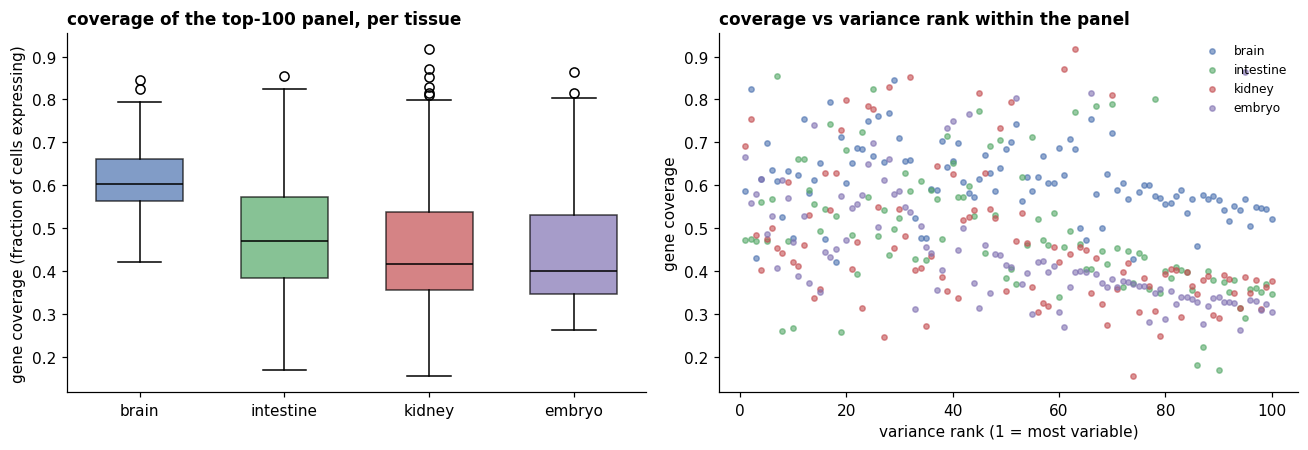

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# Left: coverage distribution per tissue (boxplot)
cov_data, labels, colors = [], [], []
for tissue in TISSUES:
    if tissue not in panels or 'coverage' not in panels[tissue].columns:
        continue
    cov_data.append(panels[tissue]['coverage'].values)
    labels.append(tissue.replace('mouse_', ''))
    colors.append(TISSUE_COLORS[tissue])

bp = axes[0].boxplot(cov_data, labels=labels, patch_artist=True, widths=0.6)
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
for median in bp['medians']:
    median.set_color('black')
axes[0].set_ylabel('gene coverage (fraction of cells expressing)')
axes[0].set_title('coverage of the top-100 panel, per tissue')

# Right: rank vs coverage (shows the variance/abundance relationship)
for tissue in TISSUES:
    if tissue not in panels or 'coverage' not in panels[tissue].columns:
        continue
    p = panels[tissue]
    axes[1].scatter(p['rank'], p['coverage'], s=12, alpha=0.6,
                    color=TISSUE_COLORS[tissue],
                    label=tissue.replace('mouse_', ''))
axes[1].set_xlabel('variance rank (1 = most variable)')
axes[1].set_ylabel('gene coverage')
axes[1].set_title('coverage vs variance rank within the panel')
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('plot_gene_panel_stats.pdf', bbox_inches='tight')
plt.show()

## Random split scheme

H&E-to-expression transfer is evaluated under random cell-level splits (70% train,
15% validation, 15% test), assigned independently per random seed. Cell counts below
are the expected partition sizes; exact counts per seed are saved by the training
runs in `splits_seed_{N}.npz`.

In [7]:
split_rows = []
for _, r in overview.iterrows():
    if pd.isna(r['n_cells']):
        continue
    split_rows.append({
        'tissue':  r['tissue'],
        'total':   int(r['n_cells']),
        'train':   int(r['n_train']),
        'val':     int(r['n_val']),
        'test':    int(r['n_test']),
        'train_%': f"{SPLIT_FRACS['train']*100:.0f}%",
        'val_%':   f"{SPLIT_FRACS['val']*100:.0f}%",
        'test_%':  f"{SPLIT_FRACS['test']*100:.0f}%",
    })
split_df = pd.DataFrame(split_rows)
print('Random split partition (70/15/15):\n')
print(split_df.to_string(index=False))

Random split partition (70/15/15):

   tissue  total  train   val  test train_% val_% test_%
    brain  30558  21390  4583  4585     70%   15%    15%
intestine  87085  60959 13062 13064     70%   15%    15%
   kidney 160922 112645 24138 24139     70%   15%    15%
   embryo 226694 158685 34004 34005     70%   15%    15%


## Spatial layout of each section

Cell centroids per tissue. Conveys section size, cell density, and tissue morphology.
Useful as a panel in a dataset overview figure.

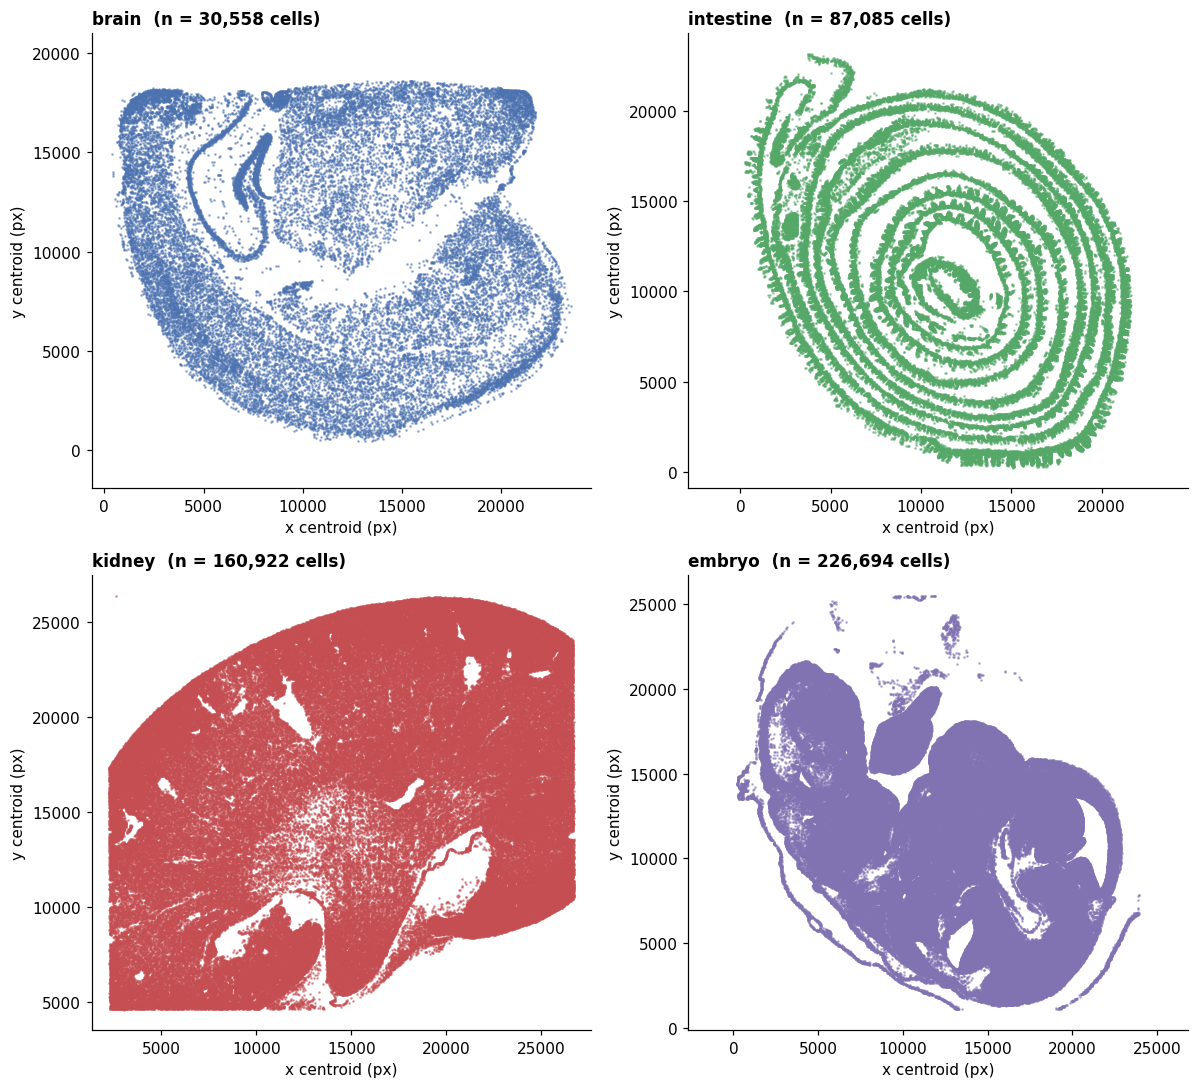

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))

for ax, tissue in zip(axes.flat, TISSUES):
    meta_p = cache_dir(tissue) / 'meta.csv'
    if not meta_p.exists():
        ax.text(0.5, 0.5, f'{tissue}: meta.csv missing',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(tissue.replace('mouse_', ''))
        continue
    meta = pd.read_csv(meta_p)
    ax.scatter(meta['x_centroid'], meta['y_centroid'], s=0.6,
               color=TISSUE_COLORS[tissue], alpha=0.5)
    ax.set_title(f"{tissue.replace('mouse_', '')}  (n = {len(meta):,} cells)")
    ax.set_xlabel('x centroid (px)')
    ax.set_ylabel('y centroid (px)')
    ax.set_aspect('equal', adjustable='datalim')

plt.tight_layout()
plt.savefig('plot_dataset_spatial.pdf', bbox_inches='tight')
plt.show()

## Draft text for the paper Data section

Fill the `{...}` placeholders from the table outputs above. This is a starting
template — adjust phrasing to your paper's voice.

---

**Visium HD mouse dataset.** We evaluated H&E-to-expression transfer on four mouse
tissues profiled with 10x Genomics Visium HD: brain, intestine, kidney, and embryo.
After cell segmentation, the four sections comprised `{n_cells}` cells respectively
(brain `{...}`, intestine `{...}`, kidney `{...}`, embryo `{...}`). For each cell we
extracted paired H&E image crops at two magnification contexts (a tight 2.5× nuclear
view and a wider 10× tissue-context view) centered on the cell centroid.

**Gene panel.** Raw gene counts were filtered to genes detected in at least `{coverage_filter}`
of cells, retaining `{n_genes_cached}` genes per tissue. From these we defined a fixed
panel of the 100 most variable genes per tissue, ranked by training-set expression
variance and selected independently of model performance. This panel was fixed prior
to model training and held constant across all experiments. The panels are enriched
for canonical cell-type markers (e.g. `{top markers per tissue}`).

**Evaluation splits.** To assess representation transfer independently of spatial
generalization, cells were partitioned into training, validation, and test sets by a
random 70/15/15 cell-level split, drawn independently for each of `{n_seeds}` random
seeds. All reported metrics are gene-wise Pearson correlation between predicted and
measured expression on held-out test cells, averaged over the 100-gene panel and over
the `{n_seeds}` seeds.

---

You should also state, somewhere in Methods, the limitation of random splits in
spatial transcriptomics (neighbor-level expression correlation can inflate
in-distribution performance) and, if you ran it, point to the spatial-grid holdout
as a sensitivity analysis under regional distribution shift.


## Files saved

- `dataset_overview.csv` — master per-tissue table (cells, genes, grid, patch sizes, split sizes)
- `gene_panel_{tissue}.csv` — top-100 gene panel per tissue with coverage + marker flag
- `plot_gene_panel_stats.pdf` — coverage distribution + coverage-vs-rank figure
- `plot_dataset_spatial.pdf` — 4-panel cell-centroid maps
